# Лабораторна робота №4

**Тема:** Генерування зображень за допомогою Stable Diffusion.

**Мета:** дослідити вплив параметрів локальної генерації, змінюючи одну змінну за раз.

**Варіант 1 — Text-to-Image.** Навчання моделі не виконується.

## 1. Теоретичний контекст

Під час навчання forward-процес додає шум до латентного представлення зображення. UNet вчиться передбачати шум за зашумленим латентом, timestep та текстовою умовою. Під час inference починаємо з випадкового латентного шуму: scheduler та UNet виконують зворотні кроки, а VAE decoder перетворює результат у пікселі. CLIP text encoder кодує prompt, але не генерує зображення. CFG задає силу текстового керування; negative prompt змінює опорну гілку CFG; seed задає стан генератора випадкових чисел.

## 2. Середовище

Шляхи визначаються відносно репозиторію. Наявний CUDA-enabled PyTorch збережено. Для кожної генерації створюється новий CPU generator.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
from IPython.display import display, Image

repo = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'labs/lab04_stable_diffusion/src/config.py').exists())
if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))
from labs.lab04_stable_diffusion.src.config import LAB_ROOT, ModelConfig
from labs.lab04_stable_diffusion.src.pipeline import environment, load_pipeline
from labs.lab04_stable_diffusion.src.experiments import experiment_groups, unique_plan
from labs.lab04_stable_diffusion.src.generation import cached_result, generate_image, save_json, audit_and_manifest
from labs.lab04_stable_diffusion.src.visualization import comparison_grid, build_figures, preview_bytes
display(environment())

{'python_version': '3.13.5',
 'versions': {'torch': '2.14.0+cu130',
  'diffusers': '0.40.0',
  'transformers': '5.17.0',
  'accelerate': '1.15.0',
  'safetensors': '0.8.0',
  'Pillow': '12.3.0',
  'numpy': '2.5.3',
  'pandas': '3.0.6',
  'matplotlib': '3.11.2',
  'nbformat': '5.11.1',
  'nbclient': '0.11.0',
  'ipykernel': '7.3.0',
  'pytest': '9.1.1'},
 'torch_version': '2.14.0+cu130',
 'diffusers_version': '0.40.0',
 'cuda_version': '13.0',
 'cuda_available': True,
 'gpu_name': 'NVIDIA GeForce RTX 3050 Laptop GPU',
 'gpu_total_bytes': 4294443008,
 'gpu_free_bytes': 3466277684,
 'ram_total_bytes': 16312721408,
 'ram_available_bytes': 2571644928,
 'disk_free_bytes': 11205595136}

## 3. План експерименту

Канонічний контроль: seed=42, steps=30, CFG=7.5, 512×512, без negative prompt. Scheduler і checkpoint фіксовані. Позначення груп не впливають на генерацію. Контрольні PNG повторно використовуються; унікальних конфігурацій рівно 13.

In [2]:
groups = experiment_groups()
plan = unique_plan()
display(pd.DataFrame([
    {'experiment': 'seed', 'variable': 'seed', 'values': '42, 123, 777, 2026', 'fixed': 'prompt, negative, steps, CFG, scheduler, resolution'},
    {'experiment': 'steps', 'variable': 'steps', 'values': '20, 30, 50', 'fixed': 'prompt, negative, seed, CFG, scheduler, resolution'},
    {'experiment': 'CFG', 'variable': 'CFG', 'values': '5, 7.5, 10', 'fixed': 'prompt, negative, seed, steps, scheduler, resolution'},
    {'experiment': 'negative', 'variable': 'negative prompt', 'values': 'None / configured; seeds 42, 123', 'fixed': 'all other controls within each pair'},
    {'experiment': 'styles', 'variable': 'style suffix', 'values': 'watercolor, isometric, photorealistic', 'fixed': 'second semantic scene and all numeric controls'},
]))
assert len(plan) == 13

,experiment,variable,values,fixed
0,seed,seed,"42, 123, 777, 2026","prompt, negative, steps, CFG, scheduler, resol..."
1,steps,steps,"20, 30, 50","prompt, negative, seed, CFG, scheduler, resolu..."
2,CFG,CFG,"5, 7.5, 10","prompt, negative, seed, steps, scheduler, reso..."
3,negative,negative prompt,"None / configured; seeds 42, 123",all other controls within each pair
4,styles,style suffix,"watercolor, isometric, photorealistic",second semantic scene and all numeric controls


## 4. Завантаження Stable Diffusion

SD 1.5 обрано для 4 ГБ VRAM. ID Runway перенаправляється на еквівалентний репозиторій SD 1.5. Використано FP16, model CPU offload та SDPA без attention slicing. Safety checker збережено. Якщо всі артефакти перевірено, повторне виконання не завантажує ваги; інакше pipeline завантажується один раз.

In [3]:
context_path = LAB_ROOT/'outputs/metadata/environment.json'
context = json.loads(context_path.read_text(encoding='utf-8')) if context_path.exists() else None
current = environment()
matching = context and all(context[k] == current[k] for k in ('versions', 'cuda_version', 'gpu_name'))
matching = matching and context['model_id'] == ModelConfig().model_id and context['revision'] == ModelConfig().revision
pipe = None
if not matching or not all(cached_result(s, context) for s in plan):
    pipe, context = load_pipeline()
    save_json(context_path, context)
display({k: context[k] for k in ('model_id', 'revision', 'pipeline_class', 'scheduler', 'dtype', 'device_strategy', 'attention_processors', 'model_load_seconds')})

{'model_id': 'stable-diffusion-v1-5/stable-diffusion-v1-5',
 'revision': '451f4fe16113bff5a5d2269ed5ad43b0592e9a14',
 'pipeline_class': 'StableDiffusionPipeline',
 'scheduler': 'PNDMScheduler',
 'dtype': 'torch.float16',
 'device_strategy': 'model_cpu_offload',
 'attention_processors': ['AttnProcessor2_0'],
 'model_load_seconds': 42.3740747999982}

## 5. Базова генерація

Перша канонічна генерація є smoke test. Помилка зупиняє notebook до наступних експериментів.

Reuse baseline: b0126393ec9c8f32


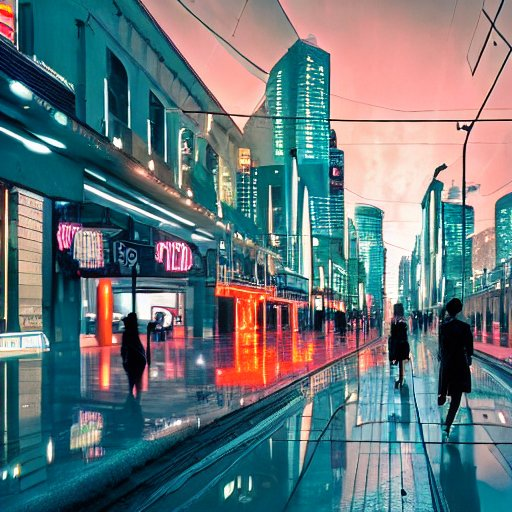

{'prompt': 'a futuristic city street at sunset, neon signs, wet pavement reflections, detailed architecture, cinematic lighting, pedestrians in the distance',
 'negative_prompt': None,
 'seed': 42,
 'num_inference_steps': 30,
 'guidance_scale': 7.5,
 'width': 512,
 'height': 512,
 'generation_time_seconds': 18.875944199971855}

In [4]:
baseline = generate_image(pipe, groups['baseline'][0], context)
display(Image(data=preview_bytes(LAB_ROOT/baseline['image_path']), width=420))
display({k: baseline[k] for k in ('prompt', 'negative_prompt', 'seed', 'num_inference_steps', 'guidance_scale', 'width', 'height', 'generation_time_seconds')})

## 6. Вплив seed

Reuse baseline: b0126393ec9c8f32


Reuse seed_123: c70912f4c52d78f2


Reuse seed_777: 7affba1680719baf


Reuse seed_2026: 414add8d725e944c


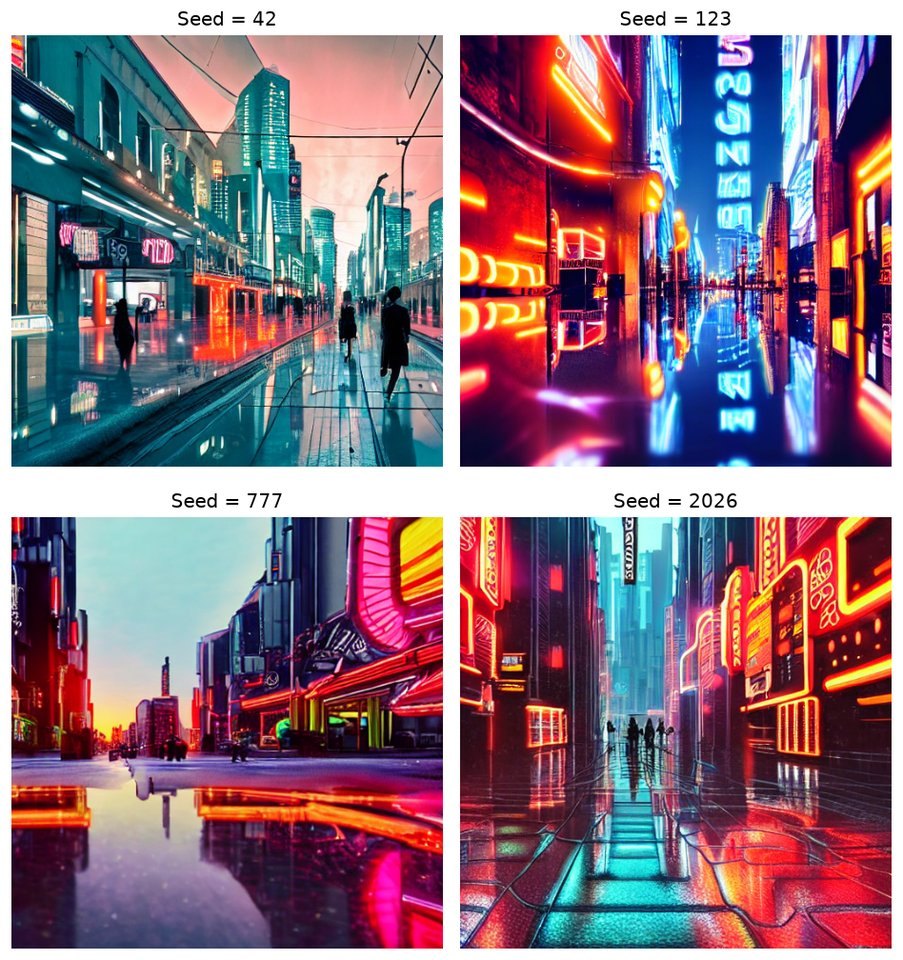

In [5]:
specs = groups['seed']
records = [generate_image(pipe, s, context) for s in specs]
figure = comparison_grid(records, [f'Seed = {s.seed}' for s in specs], LAB_ROOT/'outputs/figures/seed_comparison.png', columns=2)
display(Image(data=preview_bytes(figure), width=720))

Seed змінив композицію і палітру: 42 — відкрита вулиця з рожевим небом та пішоходами справа; 123 — вузький простір між яскравими синьо-червоними вивісками; 777 — низький ракурс із широкою калюжею; 2026 — коридор висотних будівель із центральною групою силуетів. Незмінний prompt не задає єдиного розташування об’єктів.

## 7. Вплив num_inference_steps

Reuse steps_20: 64dcbe04381d7d04


Reuse baseline: b0126393ec9c8f32


Reuse steps_50: c46e62b7a4e647bf


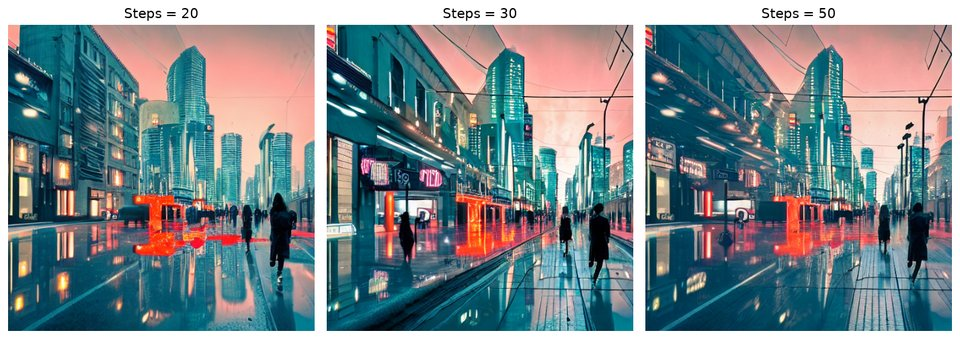

,num_inference_steps,generation_time_seconds
0,20,6.764642
1,30,18.875944
2,50,13.949547


In [6]:
specs = groups['steps']
records = [generate_image(pipe, s, context) for s in specs]
figure = comparison_grid(records, [f'Steps = {s.num_inference_steps}' for s in specs], LAB_ROOT/'outputs/figures/steps_comparison.png', columns=3)
display(Image(data=preview_bytes(figure), width=960))
display(pd.DataFrame(records)[['num_inference_steps', 'generation_time_seconds']])

Усі три зображення зберігають центральну висотну будівлю й рожеве небо. На 20 кроках передній план більше схожий на суцільну відбивну поверхню; на 30 і 50 з’являються виразніші лінії мощення/колій. На 50 змінюються фасад зліва та дрібні об’єкти, але однозначної переваги якості над 30 не видно. Час: 20 — 6,76 с; 30 — 18,88 с; 50 — 13,95 с. 30-крокова baseline була першою генерацією, тому ефект прогрівання й стан пам’яті не дозволяють ранжувати швидкість за цими одиничними вимірами.

## 8. Вплив CFG

Reuse cfg_5.0: aa1b492b771195d0


Reuse baseline: b0126393ec9c8f32


Reuse cfg_10.0: ebfcf9ee1546f35c


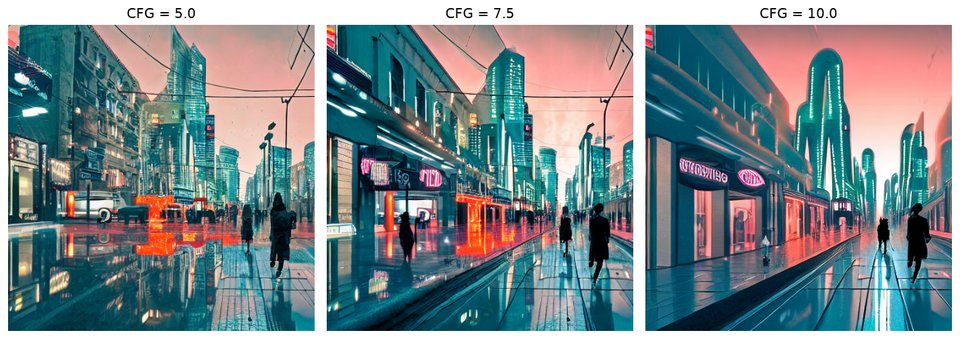

In [7]:
specs = groups['cfg']
records = [generate_image(pipe, s, context) for s in specs]
figure = comparison_grid(records, [f'CFG = {s.guidance_scale}' for s in specs], LAB_ROOT/'outputs/figures/cfg_comparison.png', columns=3)
display(Image(data=preview_bytes(figure), width=960))

За CFG 5 фасад зліва має більше дрібних вікон і присутні автомобілі. За 7,5 центральна башта зберігається, змінюються фасад і мощення. За 10 башти стають гладкими округлими формами, сцена — більш стилізованою, а великі кольорові площини виразнішими. Збільшення CFG змінило також геометрію, тому його не можна трактувати як універсальне покращення або «точність».

## 9. Negative prompt

Reuse baseline: b0126393ec9c8f32


Reuse negative_42: 8e89d4e192639eb6


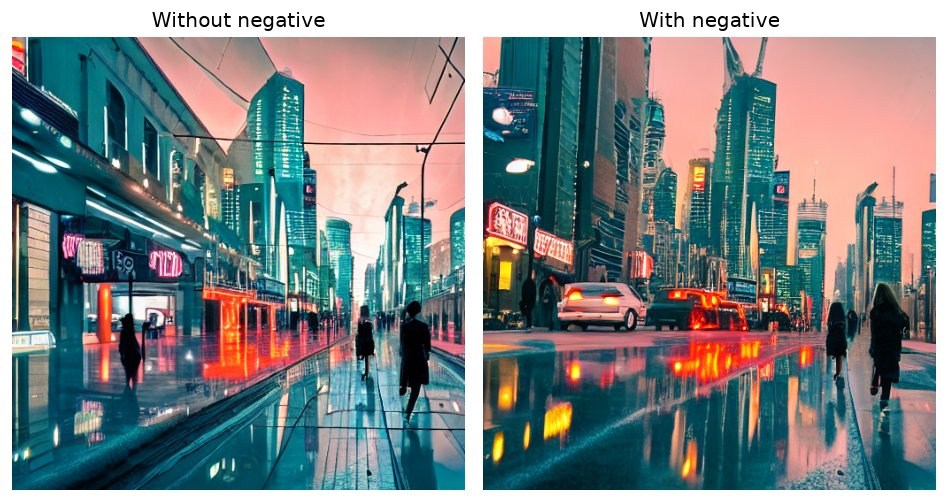

In [8]:
specs = groups['negative_prompt_seed42']
records = [generate_image(pipe, s, context) for s in specs]
figure = comparison_grid(records, ['Without negative', 'With negative'], LAB_ROOT/'outputs/figures/negative_prompt_seed42_comparison.png', columns=2)
display(Image(data=preview_bytes(figure), width=720))

Для seed 42 negative prompt змінив фасади, центральну башту та транспорт: автомобілі на лівій частині вулиці стали помітнішими, відбиття — ширшими. Це не локальне видалення недоліків зі сталої картинки: композиція також змінилась. Силуети людей залишаються нечіткими.

## 9. Negative prompt: друга пара

Reuse seed_123: c70912f4c52d78f2


Reuse negative_123: 3219f732277a6baf


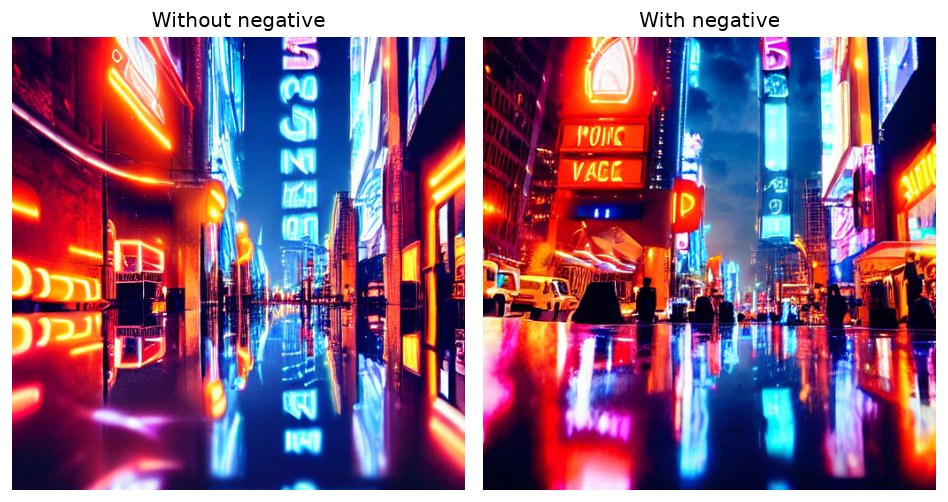

In [9]:
specs = groups['negative_prompt_seed123']
records = [generate_image(pipe, s, context) for s in specs]
figure = comparison_grid(records, ['Without negative', 'With negative'], LAB_ROOT/'outputs/figures/negative_prompt_seed123_comparison.png', columns=2)
display(Image(data=preview_bytes(figure), width=720))

Для seed 123 з negative prompt видно більше людей та автомобілів; великі вертикальні вивіски й характер відбиттів змінилися. Попри слово text у negative prompt, псевдонаписи залишилися. Воно також частково конфліктує з neon signs у positive prompt; гарантованого вилучення тексту чи всіх артефактів немає.

## 10. Стилістичне керування

Reuse style_watercolor: ea7a27507297f706


Reuse style_isometric: 84c488a353f37a54


Reuse style_photorealistic: df410b01ba0eea49


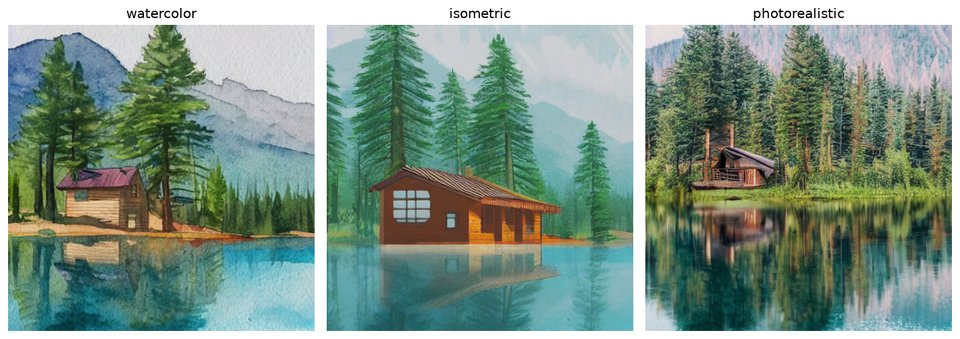

In [10]:
specs = groups['styles']
records = [generate_image(pipe, s, context) for s in specs]
figure = comparison_grid(records, [s.style for s in specs], LAB_ROOT/'outputs/figures/styles_comparison.png', columns=3)
display(Image(data=preview_bytes(figure), width=960))

У всіх трьох результатах впізнаються хатина, озеро й хвойні дерева. Watercolor має зернисту фактуру паперу й акварельні заливки; isometric — простішу геометрію хатини та ілюстративні дерева, але не демонструє строгої ізометричної проєкції; photorealistic — дрібнішу фактуру лісу й природніше відбиття. Стильовий suffix змінює і композицію: однаковий seed не фіксує геометрію при іншому тексті.

## 11. Зведення результатів

Перевіряємо повні конфігурації, контрольні суми та розміри PNG перед збереженням manifest.

In [11]:
records = audit_and_manifest(plan, context)
manifest = pd.DataFrame(records)
display(manifest[['experiment', 'case_id', 'seed', 'num_inference_steps', 'guidance_scale', 'negative_prompt', 'scheduler', 'generation_time_seconds']])
assert len(manifest) == 13

,experiment,case_id,seed,num_inference_steps,guidance_scale,negative_prompt,scheduler,generation_time_seconds
0,baseline,baseline,42,30,7.5,NaN,PNDMScheduler,18.875944
1,seed,seed_123,123,30,7.5,NaN,PNDMScheduler,10.177380
2,seed,seed_777,777,30,7.5,NaN,PNDMScheduler,9.196302
3,seed,seed_2026,2026,30,7.5,NaN,PNDMScheduler,9.678115
4,steps,steps_20,42,20,7.5,NaN,PNDMScheduler,6.764642
5,steps,steps_50,42,50,7.5,NaN,PNDMScheduler,13.949547
6,cfg,cfg_5.0,42,30,5.0,NaN,PNDMScheduler,9.559558
7,cfg,cfg_10.0,42,30,10.0,NaN,PNDMScheduler,9.146540
8,negative_prompt,negative_42,42,30,7.5,"blurry, low quality, watermark, text, distorte...",PNDMScheduler,9.262890
9,negative_prompt,negative_123,123,30,7.5,"blurry, low quality, watermark, text, distorte...",PNDMScheduler,9.160400


## 12. Час генерації

Wall-clock час виміряно через perf_counter з CUDA synchronize до/після inference. Завантаження моделі виключено. Перша baseline має ефект прогрівання; по одному вимірюванню на конфігурацію, тому це не статистичний benchmark.

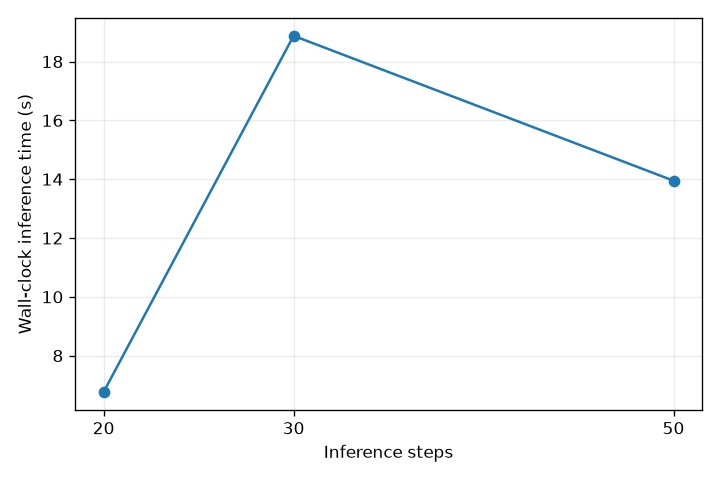

count     13.000000
min        6.764642
max       18.875944
sum      134.571691
Name: generation_time_seconds, dtype: float64

In [12]:
figures = build_figures(context)
display(Image(data=preview_bytes(figures['runtime']), width=600))
display(manifest['generation_time_seconds'].agg(['count', 'min', 'max', 'sum']))

## 13. Обмеження

SD 1.5 має обмеження дрібних деталей і написів. 4 ГБ VRAM обмежує розмір моделі; CPU offload залежить від вільної RAM. Оцінювання якісне, без метрик якості та без універсального ранжування CFG або steps. Контроль seed і параметрів не гарантує побітової тотожності між різними GPU, CUDA та версіями бібліотек. LoRA розглянуто теоретично; донавчання не виконувалось, оскільки Варіант 1 цього не вимагає. Scheduler comparison: **OPTIONAL — NOT EXECUTED**.

## 14. Висновки

Локальна SD 1.5 успішно виконала 13 унікальних генерацій. Контрольовані порівняння показали зміни композиції від seed, локальної структури від steps і геометрії від CFG. Negative prompt змінив обидві сцени, але не прибрав усі псевдонаписи. Три стильові формулювання дали різну фактуру й рівень реалізму зі збереженням основних об’єктів другої сцени; строга ізометрія не досягнута. FP16 і model CPU offload забезпечили виконання на 4 ГБ VRAM без OOM. Ці якісні спостереження стосуються лише наведеної малої серії.